In [1]:
import importlib

from models import edsr
from datasets import rekis
importlib.reload(edsr)
importlib.reload(rekis)

from models.edsr import EDSR
from datasets.rekis import ReKISDataModule

In [2]:
import torch
import lightning

In [3]:
torch.cuda.is_available()

True

In [4]:
lightning.seed_everything(42, workers=True)
rekis_module = ReKISDataModule(32, f'../../rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/')
rekis_module.setup(None)

train_loader = rekis_module.train_dataloader()
val_loader = rekis_module.val_dataloader()

Seed set to 42


In [5]:
torch.set_float32_matmul_precision("high")
trainer = lightning.Trainer(accelerator='gpu', devices=1, max_epochs=25, log_every_n_steps=1)
model = EDSR(1, 10)
model.set_loss(torch.nn.L1Loss())
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | train_metrics | MetricCollection | 0      | train
1 | val_metrics   | MetricCollection | 0      | train
2 | head          | Sequential       | 320    | train
3 | body          | Sequential       | 46.2 K | train
4 | tail          | Sequential       | 268 K  | train
5 | loss          | L1Loss           | 0      | train
-----------------------------------------------------------
315 K     Trainable params
0         Non-trainable params
315 K     Total params
1.260     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=25` reached.


In [6]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs/

Reusing TensorBoard on port 6006 (pid 20055), started 1:05:22 ago. (Use '!kill 20055' to kill it.)

In [10]:
torch.set_float32_matmul_precision("high")
trainer = lightning.Trainer(accelerator="gpu")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [7]:
checkpoint = "lightning_logs/version_11/checkpoints/epoch=24-step=1450.ckpt"
clf = EDSR.load_from_checkpoint(checkpoint).eval()
Y_edsr = torch.cat(trainer.predict(clf, val_loader))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [8]:
x, y = next(iter(train_loader))

In [9]:
x.shape, clf(x).shape, y.shape

(torch.Size([32, 1, 40, 40]),
 torch.Size([32, 1, 400, 400]),
 torch.Size([32, 1, 400, 400]))

In [10]:
clf(x)[0].squeeze().shape

torch.Size([400, 400])

In [14]:
Y_bicubic = torch.nn.functional.interpolate(
    x,
    scale_factor=10,
    mode="bicubic",
)

In [15]:
with torch.no_grad():
    Y_edsr = clf(x)

MAE bicubic: tensor(0.1701)
MAE EDSR: tensor(0.2050)


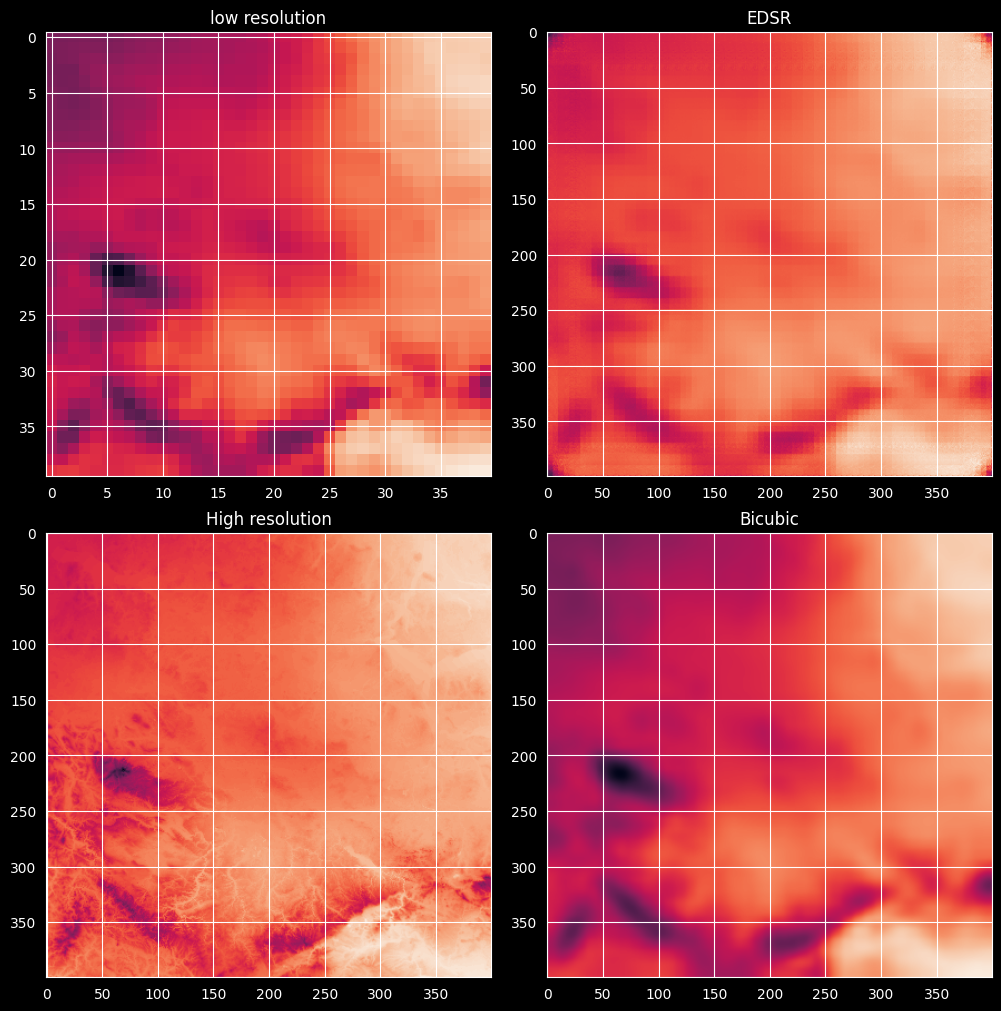

In [21]:
import random
import matplotlib.pyplot as plt

i = random.randint(0, 32)

# i = 5

fig, axes = plt.subplots(ncols=2, nrows=2, constrained_layout=True, figsize=(10, 10))
axes[0, 0].set_title("low resolution")
axes[0, 0].imshow(x[i].squeeze())
axes[0, 1].set_title("EDSR")
axes[0, 1].imshow(Y_edsr[i].squeeze())
axes[1, 0].set_title("High resolution")
axes[1, 0].imshow(y[i].squeeze())
axes[1, 1].set_title("Bicubic")
axes[1, 1].imshow(Y_bicubic[i].squeeze())

print('MAE bicubic:', (y[i] - Y_bicubic[i]).abs().mean())
print('MAE EDSR:', (y[i] - Y_edsr[i]).abs().mean())